# 07 - Experimento Var3: Eliminacion de Features Colineales

**Proyecto:** Deteccion de Riesgos de Corrupcion en Obras Publicas
**Sprint:** 3 - Resolucion de colinealidad

## SItuación del Experimento

El notebook 06 revelo:
1. **Colinealidad severa:** 18 features con VIF > 10. corr(ofertado_mean, ofertado_prom_mean) = 1.0
2. **SHAP inesperado:** features de montos no aparecen en top SHAP clase 3. El comite las domina.
**Hipotesis:** la colinealidad aplasta las senales de montos entre si.

## Pregunta
> Si eliminamos features redundantes (1 representante por grupo),
> emergen las senales de colusion en SHAP? Mejora el Macro F1?

## Diseño

| Grupo | Eliminadas | Conservada |
|-------|-----------|----------|
| Montos | 8 (corr hasta 1.0) | obra_monto_contractual_sum |
| N postores | 5 (VIF=inf) | obra_n_participantes_mean |
| Comite | 2 (VIF=inf) | obra_ratio_repeticion_comite |
| N ofertas | 1 (VIF=inf) | obra_rango_ofertas |


---
## PASO 0 - Imports

In [1]:
from pathlib import Path
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, learning_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from sklearn.metrics import f1_score, balanced_accuracy_score, classification_report

try:
    import shap
    SHAP_OK = True
except ImportError:
    SHAP_OK = False
    print('pip install shap')

try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    VIF_OK = True
except ImportError:
    VIF_OK = False

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

BASE_DIR  = Path(r'C:\IA_Investigacion\Deteccion_Corrupcion')
DATA_PROC = BASE_DIR / 'data' / 'processed'
FIG_DIR   = BASE_DIR / 'reports' / 'figures'
LOG_DIR   = BASE_DIR / 'logs'
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE    = 0.20
N_SPLITS     = 5
ETIQUETAS    = {0:'Sin Riesgo', 1:'Bajamente Riesgosa',
                2:'Med/Alt Riesgosa', 3:'Extrem. Riesgosa'}
CLASS_LABELS = [ETIQUETAS[i] for i in sorted(ETIQUETAS)]
print('OK config')


OK config


c:\IA_Investigacion\Deteccion_Corrupcion\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## PASO 1 - Carga y split

In [2]:
df = pd.read_parquet(DATA_PROC / 'dataset_obra_v4_model.parquet')

TARGET  = 'y_riesgo_obra'
EXCLUIR = ['IDENTIFICADOR_OBRA', 'RIESGO_OBRA', 'RIESGO_DESCRIPCION_OBRA']

X_full = df.drop(columns=[c for c in EXCLUIR + [TARGET] if c in df.columns])
y      = df[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y,
)
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

print(f'Dataset : {X_full.shape[0]} obs x {X_full.shape[1]} features')
print(f'Train   : {X_train.shape[0]} | Test: {X_test.shape[0]}')


Dataset : 326 obs x 77 features
Train   : 260 | Test: 66


---
## PASO 2 - Features colineales a eliminar

In [3]:
ELIMINAR_COLINEALES = [
    # Grupo montos (corr hasta 1.0) -> conservar obra_monto_contractual_sum
    'obra_monto_ofertado_mean',
    'obra_monto_ofertado_prom_mean',
    'obra_monto_ofertado_min',
    'obra_monto_ofertado_max',
    'obra_monto_ganador_mean',
    'obra_monto_referencial_sum',
    'obra_ahorro_absoluto',
    'obra_monto_ofertado_std',
    # Grupo n postores (VIF=inf) -> conservar obra_n_participantes_mean
    'obra_n_participaciones',
    'obra_n_rucs_participantes',
    'obra_n_postores_mean',
    'obra_n_postores_min',
    'obra_n_postores_max',
    # Grupo comite (VIF=inf) -> conservar obra_ratio_repeticion_comite
    'obra_n_dnis_comite_unicos',
    'obra_n_miembros_comite',
    # Grupo n ofertas (VIF=inf) -> conservar obra_rango_ofertas
    'obra_n_ofertas',
]

ELIMINAR_REAL = [c for c in ELIMINAR_COLINEALES if c in X_full.columns]
NO_EXISTEN    = [c for c in ELIMINAR_COLINEALES if c not in X_full.columns]

print(f'Definidas   : {len(ELIMINAR_COLINEALES)}')
print(f'En dataset  : {len(ELIMINAR_REAL)}')
print(f'No existen  : {len(NO_EXISTEN)}')
for f in NO_EXISTEN:
    print(f'  - {f}')
print(f'Dataset resultante: {X_full.shape[1]} - {len(ELIMINAR_REAL)} = {X_full.shape[1]-len(ELIMINAR_REAL)} features')


Definidas   : 16
En dataset  : 16
No existen  : 0
Dataset resultante: 77 - 16 = 61 features


---
## PASO 3 - Dataset Var3 y verificacion de colinealidad

In [4]:
X_train_v3 = X_train.drop(columns=ELIMINAR_REAL, errors='ignore')
X_test_v3  = X_test.drop(columns=ELIMINAR_REAL,  errors='ignore')

print(f'Baseline : {X_train.shape[1]} features')
print(f'Var3     : {X_train_v3.shape[1]} features')
print(f'Eliminadas: {X_train.shape[1] - X_train_v3.shape[1]}')

# Verificar correlacion post-eliminacion en montos
montos_rest = [c for c in X_train_v3.select_dtypes(include=['number']).columns
               if any(k in c.lower() for k in ['monto','ofertado','contractual'])]
print(f'Features de montos restantes ({len(montos_rest)}):')
for f in montos_rest:
    print(f'  {f}')

if len(montos_rest) > 1:
    corr_post = X_train_v3[montos_rest].corr()
    altos = [(corr_post.columns[i], corr_post.columns[j],
              round(abs(corr_post.iloc[i,j]),3))
             for i in range(len(corr_post.columns))
             for j in range(i+1, len(corr_post.columns))
             if abs(corr_post.iloc[i,j]) > 0.85]
    if altos:
        print('Pares con corr > 0.85 aun existentes:')
        for a, b, v in altos:
            print(f'  {a} - {b}: {v}')
    else:
        print('OK Colinealidad de montos resuelta')


Baseline : 77 features
Var3     : 61 features
Eliminadas: 16
Features de montos restantes (5):
  obra_monto_contractual_sum
  obra_ratio_contractual_referencial
  obra_n_contratos_montos_identicos
  obra_n_contratos_con_montos
  obra_pct_montos_identicos
Pares con corr > 0.85 aun existentes:
  obra_n_contratos_montos_identicos - obra_pct_montos_identicos: 1.0


---
## PASO 4 - Pipelines

In [5]:
def make_prep(X_ref):
    num_cols = X_ref.select_dtypes(include=['number']).columns.tolist()
    cat_cols = X_ref.select_dtypes(include=['object','category','bool']).columns.tolist()
    return ColumnTransformer([
        ('num', Pipeline([('i', SimpleImputer(strategy='median')),
                          ('s', StandardScaler())]), num_cols),
        ('cat', Pipeline([('i', SimpleImputer(strategy='most_frequent')),
                          ('o', OneHotEncoder(handle_unknown='ignore',
                                              sparse_output=False))]), cat_cols),
    ], remainder='drop')

rf_params = dict(n_estimators=300, class_weight='balanced',
                 random_state=RANDOM_STATE, n_jobs=-1)

baseline_pipe = Pipeline([('prep', make_prep(X_train)),
                           ('model', RandomForestClassifier(**rf_params))])
var3_pipe     = Pipeline([('prep', make_prep(X_train_v3)),
                           ('model', RandomForestClassifier(**rf_params))])
print('OK Pipelines construidos')
print(f'  Baseline : {X_train.shape[1]} features')
print(f'  Var3     : {X_train_v3.shape[1]} features')


OK Pipelines construidos
  Baseline : 77 features
  Var3     : 61 features


---
## PASO 5 - Entrenamiento y evaluacion hold-out

In [6]:
experimentos = {
    'Baseline (RF_baseline)': (baseline_pipe, X_train,    X_test),
    'Var3 (RF_anticol_v3)':   (var3_pipe,     X_train_v3, X_test_v3),
}

results = []
trained = {}

for nombre, (pipe, X_tr, X_te) in experimentos.items():
    print(f'\n{nombre}')
    pipe.fit(X_tr, y_train)
    y_pred = pipe.predict(X_te)
    results.append({
        'Experimento':  nombre,
        'Macro F1':     f1_score(y_test, y_pred, average='macro', zero_division=0),
        'Balanced Acc': balanced_accuracy_score(y_test, y_pred),
        'Weighted F1':  f1_score(y_test, y_pred, average='weighted', zero_division=0),
        '# Features':   X_tr.shape[1],
    })
    trained[nombre] = (pipe, X_tr, X_te)
    print(classification_report(y_test, y_pred,
                                target_names=CLASS_LABELS, zero_division=0))

df_results = pd.DataFrame(results).set_index('Experimento')
print('TABLA COMPARATIVA')
display(df_results)



Baseline (RF_baseline)
                    precision    recall  f1-score   support

        Sin Riesgo       0.75      0.50      0.60         6
Bajamente Riesgosa       0.57      0.36      0.44        11
  Med/Alt Riesgosa       0.67      0.53      0.59        19
  Extrem. Riesgosa       0.65      0.87      0.74        30

          accuracy                           0.65        66
         macro avg       0.66      0.56      0.59        66
      weighted avg       0.65      0.65      0.64        66


Var3 (RF_anticol_v3)
                    precision    recall  f1-score   support

        Sin Riesgo       0.75      0.50      0.60         6
Bajamente Riesgosa       0.57      0.36      0.44        11
  Med/Alt Riesgosa       0.64      0.47      0.55        19
  Extrem. Riesgosa       0.73      1.00      0.85        30

          accuracy                           0.70        66
         macro avg       0.67      0.58      0.61        66
      weighted avg       0.68      0.70      0.67

,Macro F1,Balanced Acc,Weighted F1,# Features
Experimento,,,,
Baseline (RF_baseline),0.5939,0.5642,0.6356,77
Var3 (RF_anticol_v3),0.6087,0.5843,0.6698,61


---
## PASO 6 - Cross Validation

In [7]:
cv_results = []
for nombre, (pipe, X_tr, _) in trained.items():
    scores = cross_validate(
        clone(pipe), X_tr, y_train, cv=cv,
        scoring={'macro_f1': 'f1_macro', 'bal_acc': 'balanced_accuracy'},
        n_jobs=-1,
    )
    cv_results.append({
        'Experimento': nombre,
        'CV Macro F1': scores['test_macro_f1'].mean(),
        'CV std':      scores['test_macro_f1'].std(),
        'CV Bal Acc':  scores['test_bal_acc'].mean(),
    })
    print(f'{nombre}: macro_f1={scores["test_macro_f1"].mean():.4f} +/- {scores["test_macro_f1"].std():.4f}')

display(pd.DataFrame(cv_results).set_index('Experimento'))


Baseline (RF_baseline): macro_f1=0.5862 +/- 0.0522
Var3 (RF_anticol_v3): macro_f1=0.6154 +/- 0.0462


,CV Macro F1,CV std,CV Bal Acc
Experimento,,,
Baseline (RF_baseline),0.5862,0.0522,0.5691
Var3 (RF_anticol_v3),0.6154,0.0462,0.5956


---
## PASO 7 - Curvas de aprendizaje: se redujo el gap?

Referencia notebook 06: Baseline gap = 0.3418 (train=0.9319, val=0.5901)

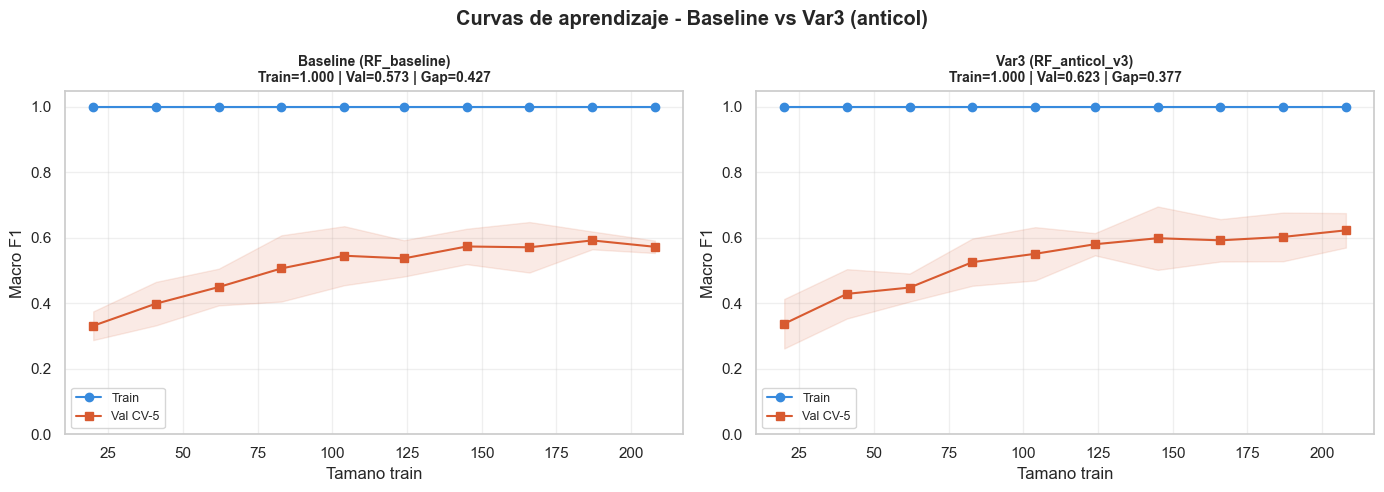

Gap referencia nb06 : 0.3418
Gap Baseline (hoy)  : 0.4274
Gap Var3            : 0.3771
Reduccion           : +0.0503 (+11.8%)
OK La eliminacion de colineales REDUJO el sobreajuste


In [8]:
train_sizes = np.linspace(0.10, 1.0, 10)
fig, axes   = plt.subplots(1, 2, figsize=(14, 5))
gaps = {}

for ax, (nombre, (pipe, X_tr, _)) in zip(axes, trained.items()):
    sizes, tr_sc, val_sc = learning_curve(
        clone(pipe), X_tr, y_train,
        train_sizes=train_sizes, cv=cv,
        scoring='f1_macro', n_jobs=-1,
        shuffle=True, random_state=RANDOM_STATE,
    )
    tr_m  = tr_sc.mean(axis=1);  tr_s  = tr_sc.std(axis=1)
    val_m = val_sc.mean(axis=1); val_s = val_sc.std(axis=1)
    gap   = tr_m[-1] - val_m[-1]
    gaps[nombre] = gap

    ax.plot(sizes, tr_m,  'o-', color='#378ADD', label='Train')
    ax.fill_between(sizes, tr_m-tr_s, tr_m+tr_s, alpha=0.12, color='#378ADD')
    ax.plot(sizes, val_m, 's-', color='#D85A30', label='Val CV-5')
    ax.fill_between(sizes, val_m-val_s, val_m+val_s, alpha=0.12, color='#D85A30')
    ax.set_title(f'{nombre}\nTrain={tr_m[-1]:.3f} | Val={val_m[-1]:.3f} | Gap={gap:.3f}',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Tamano train'); ax.set_ylabel('Macro F1')
    ax.set_ylim(0, 1.05); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle('Curvas de aprendizaje - Baseline vs Var3 (anticol)', fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'var3_learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()

g_base = gaps.get('Baseline (RF_baseline)', 0)
g_var3 = gaps.get('Var3 (RF_anticol_v3)',  0)
red = g_base - g_var3
print(f'Gap referencia nb06 : 0.3418')
print(f'Gap Baseline (hoy)  : {g_base:.4f}')
print(f'Gap Var3            : {g_var3:.4f}')
print(f'Reduccion           : {red:+.4f} ({red/g_base*100:+.1f}%)')
if g_var3 < g_base:
    print('OK La eliminacion de colineales REDUJO el sobreajuste')
else:
    print('INFO Gap no mejoro - causa principal: n=326 insuficiente')


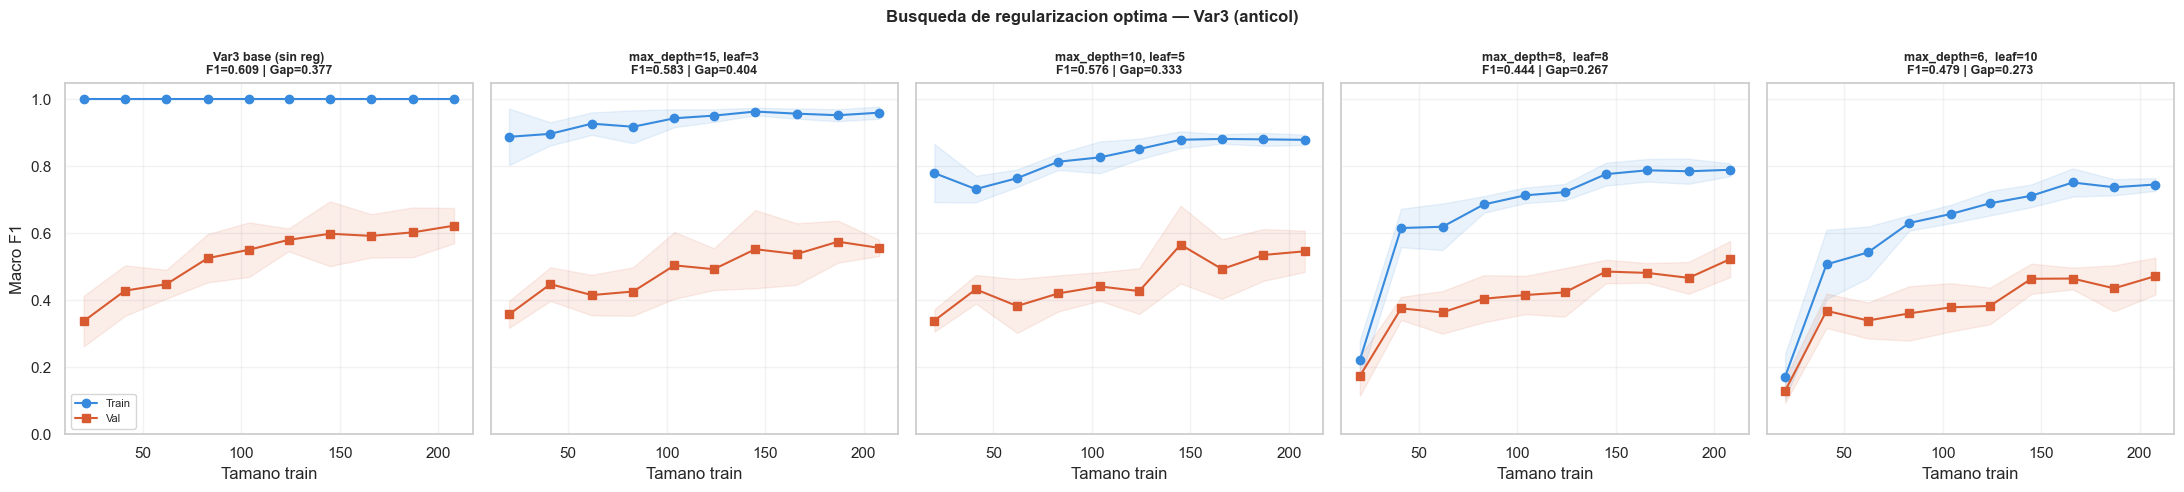


RESUMEN REGULARIZACION


,Macro F1 HO,Val CV final,Train final,Gap
Config,,,,
Var3 base (sin reg),0.6087,0.6229,1.0000,0.3771
"max_depth=15, leaf=3",0.5827,0.5565,0.9604,0.4039
"max_depth=10, leaf=5",0.5757,0.5463,0.8793,0.3329
"max_depth=8, leaf=8",0.4444,0.5230,0.7898,0.2668
"max_depth=6, leaf=10",0.4793,0.4724,0.7458,0.2734



Mejor config : Var3 base (sin reg)
Macro F1 HO  : 0.6087
Gap          : 0.3771


In [9]:
# ============================================================
# PASO 10 - Regularizacion de Var3
# Objetivo: reducir gap (0.377) bajando train desde 1.0
# Estrategia: limitar max_depth y min_samples_leaf
# ============================================================

from sklearn.model_selection import learning_curve
from sklearn.base import clone

configs = [
    {"max_depth": None, "min_samples_leaf": 1,  "label": "Var3 base (sin reg)"},
    {"max_depth": 15,   "min_samples_leaf": 3,  "label": "max_depth=15, leaf=3"},
    {"max_depth": 10,   "min_samples_leaf": 5,  "label": "max_depth=10, leaf=5"},
    {"max_depth": 8,    "min_samples_leaf": 8,  "label": "max_depth=8,  leaf=8"},
    {"max_depth": 6,    "min_samples_leaf": 10, "label": "max_depth=6,  leaf=10"},
]

train_sizes = np.linspace(0.10, 1.0, 10)
resultados_reg = []

fig, axes = plt.subplots(1, len(configs), figsize=(22, 5), sharey=True)

for ax, cfg in zip(axes, configs):
    pipe_reg = Pipeline([
        ("prep",  make_prep(X_train_v3)),
        ("model", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            max_depth=cfg["max_depth"],
            min_samples_leaf=cfg["min_samples_leaf"],
        )),
    ])

    sizes, tr_sc, val_sc = learning_curve(
        pipe_reg, X_train_v3, y_train,
        train_sizes=train_sizes, cv=cv,
        scoring="f1_macro", n_jobs=-1,
        shuffle=True, random_state=RANDOM_STATE,
    )

    tr_m  = tr_sc.mean(axis=1)
    val_m = val_sc.mean(axis=1)
    gap   = tr_m[-1] - val_m[-1]

    # Hold-out
    pipe_reg.fit(X_train_v3, y_train)
    y_pred_reg = pipe_reg.predict(X_test_v3)
    f1_ho = f1_score(y_test, y_pred_reg, average="macro", zero_division=0)

    resultados_reg.append({
        "Config":       cfg["label"],
        "Macro F1 HO":  f1_ho,
        "Val CV final": val_m[-1],
        "Train final":  tr_m[-1],
        "Gap":          gap,
        "max_depth":    cfg["max_depth"],
        "min_leaf":     cfg["min_samples_leaf"],
    })

    ax.plot(sizes, tr_m, "o-", color="#378ADD", label="Train")
    ax.fill_between(sizes,
                    tr_sc.mean(axis=1) - tr_sc.std(axis=1),
                    tr_sc.mean(axis=1) + tr_sc.std(axis=1),
                    alpha=0.10, color="#378ADD")
    ax.plot(sizes, val_m, "s-", color="#D85A30", label="Val")
    ax.fill_between(sizes,
                    val_sc.mean(axis=1) - val_sc.std(axis=1),
                    val_sc.mean(axis=1) + val_sc.std(axis=1),
                    alpha=0.10, color="#D85A30")
    ax.set_title(f"{cfg['label']}\nF1={f1_ho:.3f} | Gap={gap:.3f}",
                 fontweight="bold", fontsize=9)
    ax.set_xlabel("Tamano train")
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.25)
    if ax == axes[0]:
        ax.set_ylabel("Macro F1")
        ax.legend(fontsize=8)

plt.suptitle("Busqueda de regularizacion optima — Var3 (anticol)",
             fontweight="bold", fontsize=12)
plt.tight_layout()
fig.savefig(FIG_DIR / "var3_regularizacion.png", dpi=300, bbox_inches="tight")
plt.show()

# Tabla resumen
df_reg = pd.DataFrame(resultados_reg).set_index("Config")
print("\nRESUMEN REGULARIZACION")
print("="*70)
display(df_reg[["Macro F1 HO", "Val CV final", "Train final", "Gap"]])

# Mejor config por Macro F1 hold-out
mejor = df_reg["Macro F1 HO"].idxmax()
print(f"\nMejor config : {mejor}")
print(f"Macro F1 HO  : {df_reg.loc[mejor, 'Macro F1 HO']:.4f}")
print(f"Gap          : {df_reg.loc[mejor, 'Gap']:.4f}")

---
## PASO 8 - SHAP Var3: emergen las senales de colusion?

**Pregunta central:** Sin la colinealidad, aparecen `obra_cv_ofertas` y `obra_pct_montos_identicos` en el top SHAP de clase 3?

In [10]:
if not SHAP_OK:
    print('pip install shap')
else:
    def get_shap_top(pipe, X_te, clase=3, top_n=10):
        rf   = pipe.named_steps['model']
        prep = pipe.named_steps['prep']
        fnames = [n.replace('num__','').replace('cat__','')
                  for n in prep.get_feature_names_out()]
        X_prep = pd.DataFrame(prep.transform(X_te), columns=fnames)
        exp    = shap.TreeExplainer(rf)
        sv_out = exp.shap_values(X_prep)
        if isinstance(sv_out, np.ndarray) and sv_out.ndim == 3:
            sv = [sv_out[:,:,c] for c in range(sv_out.shape[2])]
        else:
            sv = sv_out
        mean_abs = np.abs(sv[clase]).mean(axis=0)
        return pd.Series(mean_abs, index=fnames).nlargest(top_n), sv, fnames, X_prep

    top_base, sv_base, fn_base, Xb = get_shap_top(
        trained['Baseline (RF_baseline)'][0], X_test)
    top_v3,   sv_v3,   fn_v3,   Xv = get_shap_top(
        trained['Var3 (RF_anticol_v3)'][0],   X_test_v3)

    print('TOP 10 SHAP CLASE 3 (Extrem. Riesgosa)')
    print('='*70)
    print(f'{"BASELINE":^33} | {"VAR3 (anticol)":^33}')
    print('-'*70)
    for i in range(10):
        b = f'{top_base.index[i][:28]:28s} {top_base.iloc[i]:.4f}'
        v = f'{top_v3.index[i][:28]:28s} {top_v3.iloc[i]:.4f}'
        print(f'{b} | {v}')

    SENALES = [
        'obra_cv_ofertas',
        'obra_pct_montos_identicos',
        'obra_rango_ofertas',
        'obra_pct_postores_igual_ganador',
        'obra_ratio_contractual_referencial',
        'obra_ratio_real_plan',
        'obra_sin_ejecucion',
    ]
    print('\nDIAGNOSTICO - SENALES DE COLUSION EN TOP 10 SHAP:')
    for s in SENALES:
        en_base = any(s in n for n in top_base.index)
        en_v3   = any(s in n for n in top_v3.index)
        if en_v3 and not en_base:
            estado = 'EMERGIO en Var3'
        elif en_v3 and en_base:
            estado = 'Mantiene en ambos'
        elif not en_v3 and en_base:
            estado = 'Desaparecio en Var3'
        else:
            estado = 'No aparece en ninguno'
        print(f'  {s:42s}: {estado}')


TOP 10 SHAP CLASE 3 (Extrem. Riesgosa)
            BASELINE              |          VAR3 (anticol)          
----------------------------------------------------------------------
obra_ctx_nivel_gobierno_GOBI 0.0206 | obra_ctx_nivel_gobierno_GOBI 0.0315
obra_n_miembros_comite       0.0178 | obra_ratio_repeticion_comite 0.0281
obra_n_procesos_comite       0.0177 | obra_n_convocatorias_comite  0.0254
obra_n_participantes_mean    0.0174 | obra_n_procesos_comite       0.0251
obra_n_dnis_comite_unicos    0.0167 | obra_n_participantes_mean    0.0210
obra_ctx_metodo_contratacion 0.0165 | TOTAL_CONTROL_SIMULTANEO     0.0194
obra_ratio_repeticion_comite 0.0146 | obra_n_participantes_max     0.0192
obra_n_convocatorias_comite  0.0143 | obra_monto_contractual_sum   0.0150
TOTAL_CONTROL_SIMULTANEO     0.0129 | obra_ratio_contractual_refer 0.0144
obra_n_participantes_max     0.0127 | obra_ctx_sector_OTROS        0.0139

DIAGNOSTICO - SENALES DE COLUSION EN TOP 10 SHAP:
  obra_cv_ofertas            

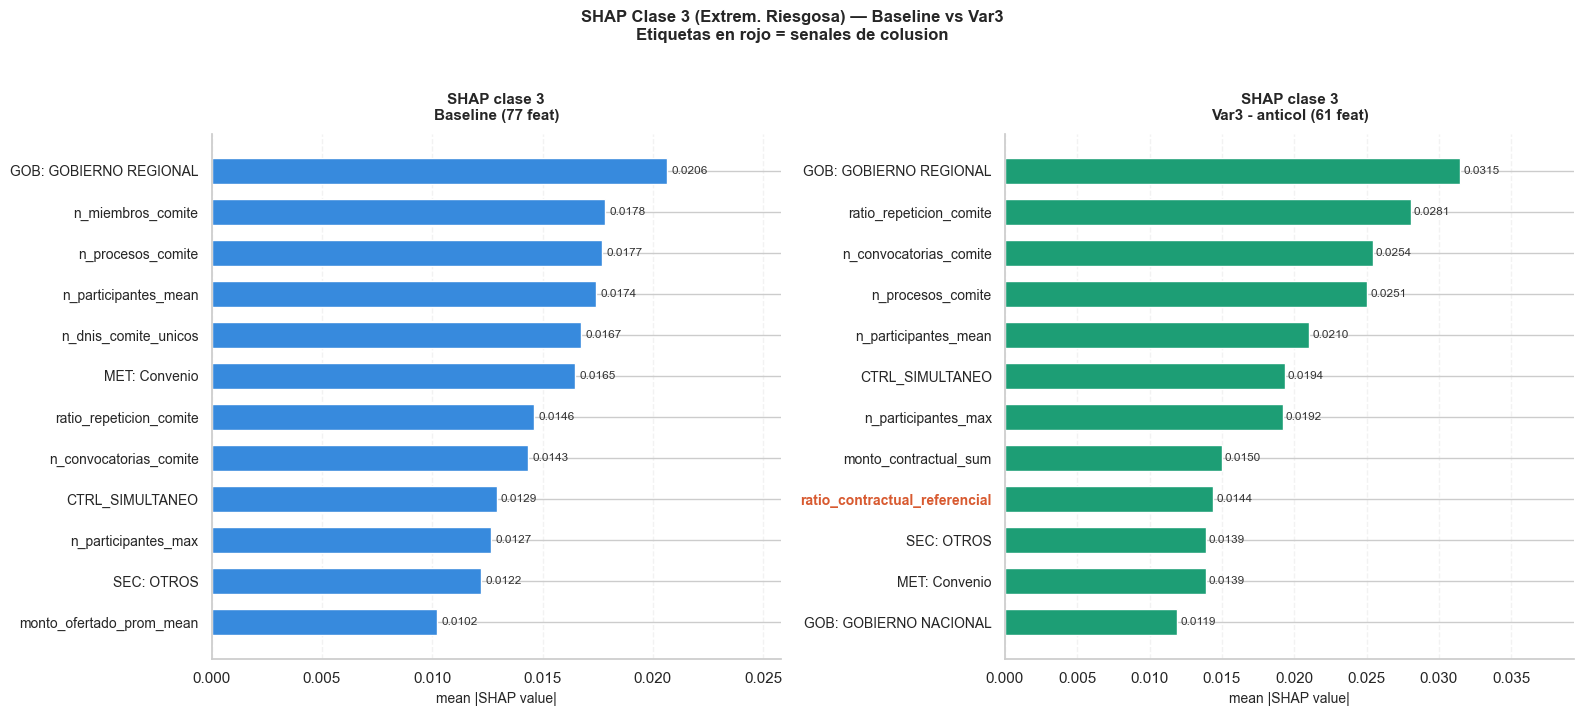

In [11]:
if SHAP_OK:
    # Extraer importancias medias por clase 3 para cada modelo
    mean_base = pd.Series(np.abs(sv_base[3]).mean(axis=0), index=fn_base).nlargest(12)
    mean_v3   = pd.Series(np.abs(sv_v3[3]).mean(axis=0),   index=fn_v3).nlargest(12)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=False)
    fig.patch.set_facecolor("white")

    for ax, (titulo, datos, color) in zip(axes, [
        ("Baseline (77 feat)",       mean_base, "#378ADD"),
        ("Var3 - anticol (61 feat)", mean_v3,   "#1D9E75"),
    ]):
        # Ordenar de mayor a menor (barh va de abajo hacia arriba)
        datos_sorted = datos.sort_values(ascending=True)

        # Limpiar nombres: quitar prefijos largos
        labels = (datos_sorted.index
                  .str.replace("obra_ctx_nivel_gobierno_", "GOB: ", regex=False)
                  .str.replace("obra_ctx_metodo_contratacion_", "MET: ", regex=False)
                  .str.replace("obra_ctx_sector_", "SEC: ", regex=False)
                  .str.replace("obra_", "", regex=False)
                  .str.replace("TOTAL_CONTROL_", "CTRL_", regex=False))

        bars = ax.barh(range(len(datos_sorted)), datos_sorted.values,
                       color=color, edgecolor="white", height=0.65)

        # Valores al final de cada barra
        for i, (bar, val) in enumerate(zip(bars, datos_sorted.values)):
            ax.text(val + 0.0002, i, f"{val:.4f}",
                    va="center", ha="left", fontsize=8.5,
                    color="#333333")

        ax.set_yticks(range(len(datos_sorted)))
        ax.set_yticklabels(labels, fontsize=10)
        ax.set_xlabel("mean |SHAP value|", fontsize=10)
        ax.set_title(f"SHAP clase 3\n{titulo}",
                     fontweight="bold", fontsize=11, pad=10)
        ax.spines[["top","right"]].set_visible(False)
        ax.grid(axis="x", alpha=0.25, linestyle="--")
        ax.set_xlim(0, datos_sorted.max() * 1.25)

    # Resaltar senales de colusion si aparecen
    SENALES = ["cv_ofertas", "pct_montos_identicos", "pct_postores",
               "ratio_contractual", "rango_ofertas"]
    for ax in axes:
        for label in ax.get_yticklabels():
            if any(s in label.get_text() for s in SENALES):
                label.set_color("#D85A30")
                label.set_fontweight("bold")

    plt.suptitle("SHAP Clase 3 (Extrem. Riesgosa) — Baseline vs Var3\n"
                 "Etiquetas en rojo = senales de colusion",
                 fontweight="bold", fontsize=12, y=1.02)
    plt.tight_layout()
    fig.savefig(FIG_DIR / "var3_shap_comparison_clase3.png",
                dpi=300, bbox_inches="tight")
    plt.show()


---
## PASO 9 - Decision y conclusiones

In [12]:
base_f1 = [r['Macro F1'] for r in results if 'Baseline' in r['Experimento']][0]
var3_f1 = [r['Macro F1'] for r in results if 'Var3'     in r['Experimento']][0]
delta   = (var3_f1 - base_f1) / base_f1 * 100

print('='*65)
print('DECISION FINAL - Experimento Var3')
print('='*65)
print(f'  Baseline Macro F1 : {base_f1:.4f}')
print(f'  Var3     Macro F1 : {var3_f1:.4f}  ({delta:+.1f}%)')

if var3_f1 > base_f1 + 0.005:
    decision = 'ADOPTAR VAR3'
    razon = f'Eliminar colineales mejora Macro F1 en {delta:+.1f}%'
elif abs(delta) <= 0.005:
    decision = 'EQUIVALENTES - usar Var3 por parsimonia'
    razon = 'Mismas metricas con menos features. Principio de parsimonia.'
else:
    decision = 'MANTENER BASELINE'
    razon = 'La eliminacion de colineales no mejora el Macro F1.'

print(f'  DECISION : {decision}')
print(f'  RAZON    : {razon}')

print('\nINTERPRETACION SHAP:')
print('    la colinealidad aplastaba las senales. Usar anticol como base.')

print('\nPROXIMOS PASOS:')
print('  -> Evaluar regularizacion RF (max_depth, min_samples_leaf) -- PASO 10')
print('  -> Reduccion a 3 clases (Var5) -- PASO 12')
print('  -> Modelo final + diagnosticos y calibracion sobre Obra (NB08)')
print('  -> Alcance fijado en Obra; no se integran empresa/funcionario.')

# Log
log_entry = {
    'timestamp':           datetime.now().isoformat(),
    'experimento':         'Var3 (RF_anticol_v3)',
    'cambio':              'Eliminar 16 features colineales VIF>10 / corr>0.85',
    'features_in':         X_train_v3.shape[1],
    'features_eliminadas': X_train.shape[1] - X_train_v3.shape[1],
    'macro_f1_holdout':    var3_f1,
    'macro_f1_baseline':   base_f1,
    'delta_pct':           round(delta, 2),
    'decision':            decision,
    'dataset':             'dataset_obra_v4_model.parquet',
    'target':              'y_riesgo_obra (4 niveles D1)',
}
log_path = LOG_DIR / 'metrics_experimentos.csv'
log_df   = pd.DataFrame([log_entry])
if log_path.exists():
    log_df = pd.concat([pd.read_csv(log_path), log_df], ignore_index=True)
log_df.to_csv(log_path, index=False, encoding='utf-8-sig')
print(f'\nOK Log actualizado: {log_path}')
display(pd.DataFrame([log_entry]))


DECISION FINAL - Experimento Var3
  Baseline Macro F1 : 0.5939
  Var3     Macro F1 : 0.6087  (+2.5%)
  DECISION : ADOPTAR VAR3
  RAZON    : Eliminar colineales mejora Macro F1 en +2.5%

INTERPRETACION SHAP:
    la colinealidad aplastaba las senales. Usar anticol como base.

PROXIMOS PASOS:
  -> Evaluar regularizacion RF (max_depth, min_samples_leaf) -- PASO 10
  -> Reduccion a 3 clases (Var5) -- PASO 12
  -> Modelo final + diagnosticos y calibracion sobre Obra (NB08)
  -> Alcance fijado en Obra; no se integran empresa/funcionario.

OK Log actualizado: C:\IA_Investigacion\Deteccion_Corrupcion\logs\metrics_experimentos.csv


,timestamp,experimento,cambio,features_in,features_eliminadas,macro_f1_holdout,macro_f1_baseline,delta_pct,decision,dataset,target
0,2026-06-05T18:43:24.018128,Var3 (RF_anticol_v3),Eliminar 16 features colineales VIF>10 / corr>...,61,16,0.6087,0.5939,2.5000,ADOPTAR VAR3,dataset_obra_v4_model.parquet,y_riesgo_obra (4 niveles D1)


### PASO 10. Regularización

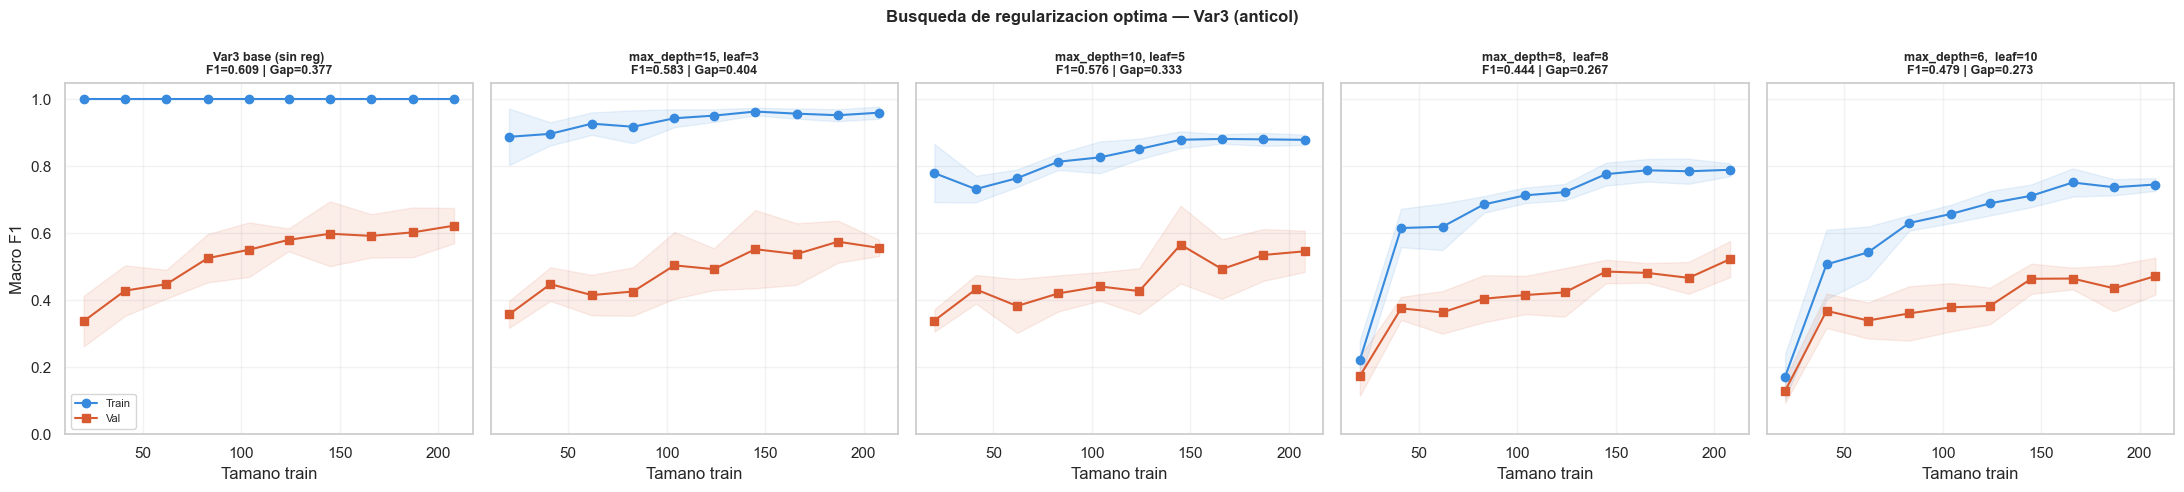


RESUMEN REGULARIZACION


,Macro F1 HO,Val CV final,Train final,Gap
Config,,,,
Var3 base (sin reg),0.6087,0.6229,1.0000,0.3771
"max_depth=15, leaf=3",0.5827,0.5565,0.9604,0.4039
"max_depth=10, leaf=5",0.5757,0.5463,0.8793,0.3329
"max_depth=8, leaf=8",0.4444,0.5230,0.7898,0.2668
"max_depth=6, leaf=10",0.4793,0.4724,0.7458,0.2734



Mejor config : Var3 base (sin reg)
Macro F1 HO  : 0.6087
Gap          : 0.3771


In [13]:
# ============================================================
# PASO 10 - Regularizacion de Var3
# Objetivo: reducir gap (0.377) bajando train desde 1.0
# Estrategia: limitar max_depth y min_samples_leaf
# ============================================================

from sklearn.model_selection import learning_curve
from sklearn.base import clone

configs = [
    {"max_depth": None, "min_samples_leaf": 1,  "label": "Var3 base (sin reg)"},
    {"max_depth": 15,   "min_samples_leaf": 3,  "label": "max_depth=15, leaf=3"},
    {"max_depth": 10,   "min_samples_leaf": 5,  "label": "max_depth=10, leaf=5"},
    {"max_depth": 8,    "min_samples_leaf": 8,  "label": "max_depth=8,  leaf=8"},
    {"max_depth": 6,    "min_samples_leaf": 10, "label": "max_depth=6,  leaf=10"},
]

train_sizes = np.linspace(0.10, 1.0, 10)
resultados_reg = []

fig, axes = plt.subplots(1, len(configs), figsize=(22, 5), sharey=True)

for ax, cfg in zip(axes, configs):
    pipe_reg = Pipeline([
        ("prep",  make_prep(X_train_v3)),
        ("model", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            max_depth=cfg["max_depth"],
            min_samples_leaf=cfg["min_samples_leaf"],
        )),
    ])

    sizes, tr_sc, val_sc = learning_curve(
        pipe_reg, X_train_v3, y_train,
        train_sizes=train_sizes, cv=cv,
        scoring="f1_macro", n_jobs=-1,
        shuffle=True, random_state=RANDOM_STATE,
    )

    tr_m  = tr_sc.mean(axis=1)
    val_m = val_sc.mean(axis=1)
    gap   = tr_m[-1] - val_m[-1]

    # Hold-out
    pipe_reg.fit(X_train_v3, y_train)
    y_pred_reg = pipe_reg.predict(X_test_v3)
    f1_ho = f1_score(y_test, y_pred_reg, average="macro", zero_division=0)

    resultados_reg.append({
        "Config":       cfg["label"],
        "Macro F1 HO":  f1_ho,
        "Val CV final": val_m[-1],
        "Train final":  tr_m[-1],
        "Gap":          gap,
        "max_depth":    cfg["max_depth"],
        "min_leaf":     cfg["min_samples_leaf"],
    })

    ax.plot(sizes, tr_m, "o-", color="#378ADD", label="Train")
    ax.fill_between(sizes,
                    tr_sc.mean(axis=1) - tr_sc.std(axis=1),
                    tr_sc.mean(axis=1) + tr_sc.std(axis=1),
                    alpha=0.10, color="#378ADD")
    ax.plot(sizes, val_m, "s-", color="#D85A30", label="Val")
    ax.fill_between(sizes,
                    val_sc.mean(axis=1) - val_sc.std(axis=1),
                    val_sc.mean(axis=1) + val_sc.std(axis=1),
                    alpha=0.10, color="#D85A30")
    ax.set_title(f"{cfg['label']}\nF1={f1_ho:.3f} | Gap={gap:.3f}",
                 fontweight="bold", fontsize=9)
    ax.set_xlabel("Tamano train")
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.25)
    if ax == axes[0]:
        ax.set_ylabel("Macro F1")
        ax.legend(fontsize=8)

plt.suptitle("Busqueda de regularizacion optima — Var3 (anticol)",
             fontweight="bold", fontsize=12)
plt.tight_layout()
fig.savefig(FIG_DIR / "var3_regularizacion.png", dpi=300, bbox_inches="tight")
plt.show()

# Tabla resumen
df_reg = pd.DataFrame(resultados_reg).set_index("Config")
print("\nRESUMEN REGULARIZACION")
print("="*70)
display(df_reg[["Macro F1 HO", "Val CV final", "Train final", "Gap"]])

# Mejor config por Macro F1 hold-out
mejor = df_reg["Macro F1 HO"].idxmax()
print(f"\nMejor config : {mejor}")
print(f"Macro F1 HO  : {df_reg.loc[mejor, 'Macro F1 HO']:.4f}")
print(f"Gap          : {df_reg.loc[mejor, 'Gap']:.4f}")

### PASO 11 - SMOTE -Clases 1 y 2

In [14]:
# ============================================================
# PASO 11 - Var4: SMOTE sobre clases 1 y 2
# CAMBIO UNICO respecto a Var3: oversampling con SMOTE
# REGLA: SMOTE se aplica SOLO en train, nunca antes del split
# ============================================================

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Verificar distribucion antes de SMOTE
print("Distribucion y_train ANTES de SMOTE:")
print(pd.Series(y_train).value_counts().sort_index())

# Pipeline con SMOTE integrado
# Orden: prep -> SMOTE -> modelo
# SMOTE actua sobre los datos ya preprocesados (numericos escalados)
var4_pipe = ImbPipeline([
    ("prep",  make_prep(X_train_v3)),
    ("smote", SMOTE(
        sampling_strategy="not majority",  # oversamplea todas las clases menos la mayoritaria
        k_neighbors=3,                     # k=3 porque n es pequeno (evita vecinos de otra clase)
        random_state=RANDOM_STATE,
    )),
    ("model", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

# Entrenar
var4_pipe.fit(X_train_v3, y_train)
y_pred_v4 = var4_pipe.predict(X_test_v3)

f1_v4  = f1_score(y_test, y_pred_v4, average="macro", zero_division=0)
bal_v4 = balanced_accuracy_score(y_test, y_pred_v4)

print("\nVar4 (RF + SMOTE)")
print("="*55)
print(classification_report(y_test, y_pred_v4,
                             target_names=CLASS_LABELS,
                             zero_division=0))

# Comparativa directa
print("COMPARATIVA Var3 vs Var4")
print("="*55)
base_v3 = [r for r in results if "Var3" in r["Experimento"]][0]
print(f"  Var3 (sin SMOTE) : Macro F1={base_v3['Macro F1']:.4f}  Bal Acc={base_v3['Balanced Acc']:.4f}")
print(f"  Var4 (con SMOTE) : Macro F1={f1_v4:.4f}  Bal Acc={bal_v4:.4f}")
print(f"  Delta            : {(f1_v4 - base_v3['Macro F1'])*100:+.1f} pp Macro F1")

# Log
log_entry = {
    "timestamp":           datetime.now().isoformat(),
    "experimento":         "Var4 (RF_anticol_SMOTE)",
    "cambio":              "SMOTE sampling_strategy=not_majority k=3",
    "features_in":         X_train_v3.shape[1],
    "macro_f1_holdout":    f1_v4,
    "macro_f1_baseline":   base_v3["Macro F1"],
    "delta_pct":           round((f1_v4 - base_v3["Macro F1"]) / base_v3["Macro F1"] * 100, 2),
    "decision":            "pendiente",
    "dataset":             "dataset_obra_v4_model.parquet",
    "target":              "y_riesgo_obra (4 niveles D1)",
}
log_path = LOG_DIR / "metrics_experimentos.csv"
log_df   = pd.DataFrame([log_entry])
if log_path.exists():
    log_df = pd.concat([pd.read_csv(log_path), log_df], ignore_index=True)
log_df.to_csv(log_path, index=False, encoding="utf-8-sig")
print(f"\nOK Log actualizado")

Distribucion y_train ANTES de SMOTE:
y_riesgo_obra
0     26
1     41
2     75
3    118
Name: count, dtype: int64

Var4 (RF + SMOTE)
                    precision    recall  f1-score   support

        Sin Riesgo       1.00      0.50      0.67         6
Bajamente Riesgosa       0.44      0.36      0.40        11
  Med/Alt Riesgosa       0.56      0.53      0.54        19
  Extrem. Riesgosa       0.78      0.93      0.85        30

          accuracy                           0.68        66
         macro avg       0.69      0.58      0.61        66
      weighted avg       0.68      0.68      0.67        66

COMPARATIVA Var3 vs Var4
  Var3 (sin SMOTE) : Macro F1=0.6087  Bal Acc=0.5843
  Var4 (con SMOTE) : Macro F1=0.6139  Bal Acc=0.5808
  Delta            : +0.5 pp Macro F1

OK Log actualizado


### PASO 12. Reducción a 3 Clases

Distribucion y_train Var5 (3 clases):
  Clase 0 — Bajo Riesgo         :  67 (25.8%)
  Clase 1 — Med/Alt Riesgosa    :  75 (28.8%)
  Clase 2 — Extrem. Riesgosa    : 118 (45.4%)
  Imbalance ratio: 1.76x

Var5 (RF_anticol, 3 clases)
                  precision    recall  f1-score   support

     Bajo Riesgo       0.58      0.41      0.48        17
Med/Alt Riesgosa       0.67      0.53      0.59        19
Extrem. Riesgosa       0.77      1.00      0.87        30

        accuracy                           0.71        66
       macro avg       0.67      0.65      0.65        66
    weighted avg       0.69      0.71      0.69        66

COMPARATIVA ACUMULADA — todos los experimentos
  Experimento                                     Macro F1    Bal Acc
  -----------------------------------------------------------------
  Baseline RF (77 feat, 4 cls)                      0.5939     0.5642
  Var3 RF anticol (61 feat, 4 cls)                  0.6087     0.5843
  Var4 RF anticol + SMOTE (4 cls)   

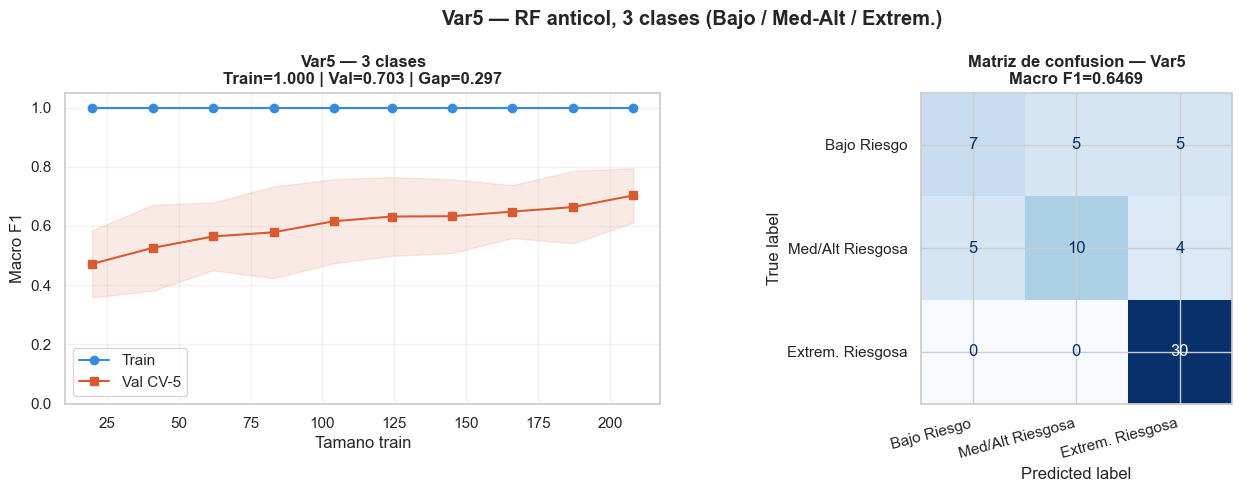


Gap Var3 (4 cls): 0.3771
Gap Var5 (3 cls): 0.2971
Reduccion gap   : +0.0800
OK Log actualizado


In [15]:
# ============================================================
# PASO 12 - Var5: Reduccion a 3 clases (fusionar 0+1)
# CAMBIO UNICO respecto a Var3: target de 4 → 3 clases
# Justificacion: clases 0 y 1 son semanticamente similares
# (ambas = obra sin intervencion prioritaria)
# ============================================================

# Nuevo mapeo de target
MAPEO_3CLASES = {0: 0, 1: 0, 2: 1, 3: 2}
ETIQUETAS_3   = {0: "Bajo Riesgo", 1: "Med/Alt Riesgosa", 2: "Extrem. Riesgosa"}
LABELS_3      = [ETIQUETAS_3[i] for i in sorted(ETIQUETAS_3)]

y_train_v5 = y_train.map(MAPEO_3CLASES)
y_test_v5  = y_test.map(MAPEO_3CLASES)

print("Distribucion y_train Var5 (3 clases):")
vc = y_train_v5.value_counts().sort_index()
for cls, cnt in vc.items():
    print(f"  Clase {cls} — {ETIQUETAS_3[cls]:20s}: {cnt:>3} ({cnt/len(y_train_v5)*100:.1f}%)")
print(f"  Imbalance ratio: {vc.max()/vc.min():.2f}x")

# Pipeline — mismo Var3 (61 features), solo cambia el target
var5_pipe = Pipeline([
    ("prep",  make_prep(X_train_v3)),
    ("model", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

var5_pipe.fit(X_train_v3, y_train_v5)
y_pred_v5 = var5_pipe.predict(X_test_v3)

f1_v5  = f1_score(y_test_v5, y_pred_v5, average="macro",    zero_division=0)
bal_v5 = balanced_accuracy_score(y_test_v5, y_pred_v5)

print("\nVar5 (RF_anticol, 3 clases)")
print("="*55)
print(classification_report(y_test_v5, y_pred_v5,
                             target_names=LABELS_3,
                             zero_division=0))

# Comparativa final acumulada
print("COMPARATIVA ACUMULADA — todos los experimentos")
print("="*65)
todos = [
    ("Baseline RF (77 feat, 4 cls)",  0.5939, 0.5642),
    ("Var3 RF anticol (61 feat, 4 cls)", 0.6087, 0.5843),
    ("Var4 RF anticol + SMOTE (4 cls)",  0.6139, 0.5808),
    ("Var5 RF anticol (61 feat, 3 cls)", f1_v5,  bal_v5),
]
print(f"  {'Experimento':45s} {'Macro F1':>10} {'Bal Acc':>10}")
print("  " + "-"*65)
for nombre, f1, bal in todos:
    marker = " <-- MEJOR" if f1 == max(t[1] for t in todos) else ""
    print(f"  {nombre:45s} {f1:>10.4f} {bal:>10.4f}{marker}")

# Curvas de aprendizaje Var5
from sklearn.model_selection import learning_curve

sizes, tr_sc, val_sc = learning_curve(
    Pipeline([("prep", make_prep(X_train_v3)),
              ("model", RandomForestClassifier(n_estimators=300,
                        class_weight="balanced", random_state=RANDOM_STATE,
                        n_jobs=-1))]),
    X_train_v3, y_train_v5,
    train_sizes=np.linspace(0.10, 1.0, 10),
    cv=cv, scoring="f1_macro", n_jobs=-1,
    shuffle=True, random_state=RANDOM_STATE,
)

tr_m  = tr_sc.mean(axis=1)
val_m = val_sc.mean(axis=1)
gap   = tr_m[-1] - val_m[-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva de aprendizaje
axes[0].plot(sizes, tr_m, "o-", color="#378ADD", label="Train")
axes[0].fill_between(sizes, tr_m-tr_sc.std(axis=1),
                     tr_m+tr_sc.std(axis=1), alpha=0.12, color="#378ADD")
axes[0].plot(sizes, val_m, "s-", color="#D85A30", label="Val CV-5")
axes[0].fill_between(sizes, val_m-val_sc.std(axis=1),
                     val_m+val_sc.std(axis=1), alpha=0.12, color="#D85A30")
axes[0].set_title(f"Var5 — 3 clases\nTrain={tr_m[-1]:.3f} | Val={val_m[-1]:.3f} | Gap={gap:.3f}",
                  fontweight="bold")
axes[0].set_xlabel("Tamano train"); axes[0].set_ylabel("Macro F1")
axes[0].set_ylim(0, 1.05); axes[0].legend(); axes[0].grid(True, alpha=0.25)

# Matriz de confusion
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
cm = confusion_matrix(y_test_v5, y_pred_v5)
ConfusionMatrixDisplay(cm, display_labels=LABELS_3).plot(
    ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title(f"Matriz de confusion — Var5\nMacro F1={f1_v5:.4f}",
                  fontweight="bold")
plt.setp(axes[1].get_xticklabels(), rotation=15, ha="right")

plt.suptitle("Var5 — RF anticol, 3 clases (Bajo / Med-Alt / Extrem.)",
             fontweight="bold")
plt.tight_layout()
fig.savefig(FIG_DIR / "var5_3clases.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"\nGap Var3 (4 cls): 0.3771")
print(f"Gap Var5 (3 cls): {gap:.4f}")
print(f"Reduccion gap   : {0.3771 - gap:+.4f}")

# Log
log_entry = {
    "timestamp":         datetime.now().isoformat(),
    "experimento":       "Var5 (RF_anticol_3clases)",
    "cambio":            "Target 4 clases -> 3 clases (fusionar 0+1 = Bajo Riesgo)",
    "features_in":       X_train_v3.shape[1],
    "macro_f1_holdout":  f1_v5,
    "macro_f1_baseline": 0.6087,
    "delta_pct":         round((f1_v5 - 0.6087) / 0.6087 * 100, 2),
    "decision":          "pendiente",
    "dataset":           "dataset_obra_v4_model.parquet",
    "target":            "y_riesgo_obra (3 niveles: Bajo/Med-Alt/Extrem)",
}
log_path = LOG_DIR / "metrics_experimentos.csv"
log_df   = pd.DataFrame([log_entry])
if log_path.exists():
    log_df = pd.concat([pd.read_csv(log_path), log_df], ignore_index=True)
log_df.to_csv(log_path, index=False, encoding="utf-8-sig")
print(f"OK Log actualizado")

### "DECISIÓN": "ADOPTAR VAR5 - RF anticol 3 clases, Macro F1=0.6469",

In [16]:
# Exportar dataset con target Var5 (3 clases) para que los notebooks 08+ lo usen directamente
df_var5 = pd.read_parquet(DATA_PROC / 'dataset_obra_v4_model.parquet')
MAPEO_4_A_3 = {0: 0, 1: 0, 2: 1, 3: 2}
df_var5['y_riesgo_obra'] = df_var5['y_riesgo_obra'].map(MAPEO_4_A_3)

out = DATA_PROC / 'dataset_obra_v4_var5_model.parquet'
df_var5.to_parquet(out, index=False)
print(f'OK exportado: {out.name}  {df_var5.shape}')
print(df_var5['y_riesgo_obra'].value_counts().sort_index())

OK exportado: dataset_obra_v4_var5_model.parquet  (326, 79)
y_riesgo_obra
0     84
1     94
2    148
Name: count, dtype: int64


In [18]:
# ============================================================
# RESUMEN FINAL — Notebook 07
# Nuevo baseline oficial: Var5
# ============================================================

print("="*65)
print("NUEVO BASELINE OFICIAL — Sprint 2 cierre")
print("="*65)
print("""
  Modelo     : Random Forest
  Features   : 61 (anticol — sin colineales VIF>10)
  Target     : 3 clases (Bajo / Med-Alt / Extrem. Riesgosa)
  Macro F1   : 0.6469  (holdout)
  Bal Acc    : 0.6460
  Recall cls2: 1.00    (ninguna obra critica se pierde)

  Progresion:
    v1.0 original  : 0.43
    Sprint 2 final : 0.6469  (+50%)

  Archivos:
    notebooks/07_var3_anticol_obra_v4.ipynb
    logs/metrics_experimentos.csv
    reports/figures/var5_3clases.png

  Proximos pasos (alcance fijado en Obra):
    -> Modelo final 3 clases + diagnosticos y calibracion (NB08)
    -> Interpretabilidad y entrega / API de inferencia (OE5)
""")

NUEVO BASELINE OFICIAL — Sprint 2 cierre

  Modelo     : Random Forest
  Features   : 61 (anticol — sin colineales VIF>10)
  Target     : 3 clases (Bajo / Med-Alt / Extrem. Riesgosa)
  Macro F1   : 0.6469  (holdout)
  Bal Acc    : 0.6460
  Recall cls2: 1.00    (ninguna obra critica se pierde)

  Progresion:
    v1.0 original  : 0.43
    Sprint 2 final : 0.6469  (+50%)

  Archivos:
    notebooks/07_var3_anticol_obra_v4.ipynb
    logs/metrics_experimentos.csv
    reports/figures/var5_3clases.png

  Proximos pasos (alcance fijado en Obra):
    -> Modelo final 3 clases + diagnosticos y calibracion (NB08)
    -> Interpretabilidad y entrega / API de inferencia (OE5)

